In [1]:
# pandas = used for tables (like Excel)
import pandas as pd

# numpy = used for calculations
import numpy as np

In [2]:
# Each row = one telecom cell site

data = {
    "cell_id": ["Cell_A", "Cell_B", "Cell_C", "Cell_D", "Cell_E"],

    # total time monitored (hours in a day)
    "total_time": [24, 24, 24, 24, 24],

    # downtime = when network was OFF
    "downtime": [0.5, 2, 0, 4, 1.5]
}

# Convert to DataFrame (table format)
df = pd.DataFrame(data)

# Show data
df

,cell_id,total_time,downtime
0,Cell_A,24,0.5
1,Cell_B,24,2.0
2,Cell_C,24,0.0
3,Cell_D,24,4.0
4,Cell_E,24,1.5


In [3]:
# uptime = total time - downtime
df["uptime"] = df["total_time"] - df["downtime"]

df

,cell_id,total_time,downtime,uptime
0,Cell_A,24,0.5,23.5
1,Cell_B,24,2.0,22.0
2,Cell_C,24,0.0,24.0
3,Cell_D,24,4.0,20.0
4,Cell_E,24,1.5,22.5


In [4]:
# Convert uptime into percentage availability
df["availability_%"] = (df["uptime"] / df["total_time"]) * 100

df

,cell_id,total_time,downtime,uptime,availability_%
0,Cell_A,24,0.5,23.5,97.916667
1,Cell_B,24,2.0,22.0,91.666667
2,Cell_C,24,0.0,24.0,100.000000
3,Cell_D,24,4.0,20.0,83.333333
4,Cell_E,24,1.5,22.5,93.750000


In [5]:
# Function to classify network quality

def classify(avail):
    if avail >= 99:
        return "Excellent 🟢"
    elif avail >= 97:
        return "Good 🟡"
    else:
        return "Poor 🔴"

# Apply function to each row
df["status"] = df["availability_%"].apply(classify)

df

,cell_id,total_time,downtime,uptime,availability_%,status
0,Cell_A,24,0.5,23.5,97.916667,Good 🟡
1,Cell_B,24,2.0,22.0,91.666667,Poor 🔴
2,Cell_C,24,0.0,24.0,100.000000,Excellent 🟢
3,Cell_D,24,4.0,20.0,83.333333,Poor 🔴
4,Cell_E,24,1.5,22.5,93.750000,Poor 🔴


In [6]:
# Find worst performing cell
worst_cell = df.loc[df["availability_%"].idxmin()]

worst_cell

cell_id              Cell_D
total_time               24
downtime                4.0
uptime                 20.0
availability_%    83.333333
status               Poor 🔴
Name: 3, dtype: object

In [7]:
# Sort cells by performance
df.sort_values(by="availability_%", ascending=False)

,cell_id,total_time,downtime,uptime,availability_%,status
2,Cell_C,24,0.0,24.0,100.000000,Excellent 🟢
0,Cell_A,24,0.5,23.5,97.916667,Good 🟡
4,Cell_E,24,1.5,22.5,93.750000,Poor 🔴
1,Cell_B,24,2.0,22.0,91.666667,Poor 🔴
3,Cell_D,24,4.0,20.0,83.333333,Poor 🔴


In [8]:
# Import plotting library
import matplotlib.pyplot as plt

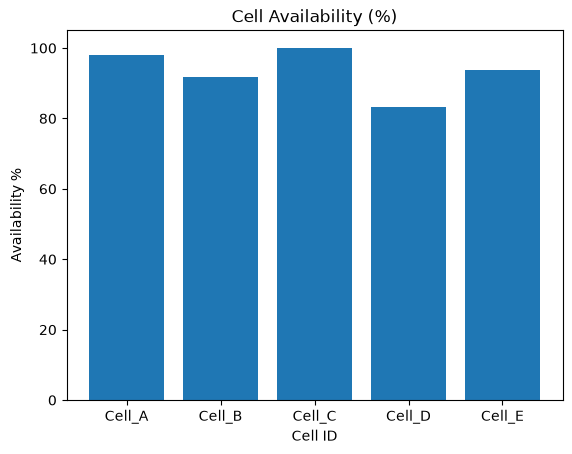

In [9]:
# Plot cell availability
plt.figure()

plt.bar(df["cell_id"], df["availability_%"])

plt.title("Cell Availability (%)")
plt.xlabel("Cell ID")
plt.ylabel("Availability %")

plt.show()

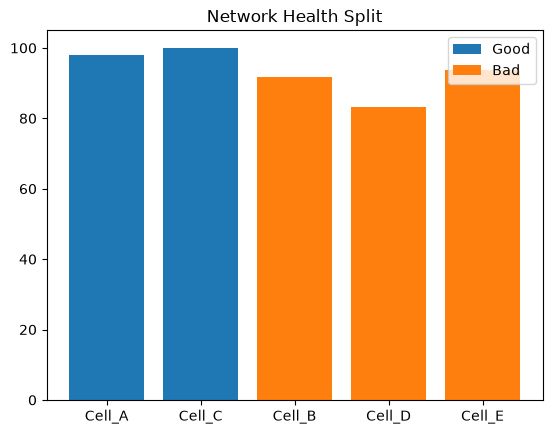

In [10]:
# Separate good vs bad cells
good = df[df["availability_%"] >= 97]
bad = df[df["availability_%"] < 97]

plt.figure()

plt.bar(good["cell_id"], good["availability_%"], label="Good")
plt.bar(bad["cell_id"], bad["availability_%"], label="Bad")

plt.title("Network Health Split")
plt.legend()

plt.show()